<a href="https://colab.research.google.com/github/MaryamBuqrain/MaryamBuQurayn_Capston_Project_Advanced_ML_Techniques/blob/main/Diabetes_Classification_Lesson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetes Prediction: From Raw Data to Evaluation


## 0. Setup

In [ ]:
import warnings
warnings. filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn. model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix
from sklearn. metrics import RocCurveDisplay, PrecisionRecallDisplay
from xgboost import XGBClassifier # from classifiying ML * !pip install xgboost lightgbm shape - q in case the module is missing
from lightgbm import LGBMClassifier # from classifiying ML
import shap
sns. set_theme(style="whitegrid",font_scale=1.1) # from plotting
COLORS = {0: "#4C72B0",1:"#DD8452"} # blue is no diabetes , orange is diabetes
LABELS = {0: "No diabetes", 1: "Diabetes"}

In [ ]:
rng= np.random.default_rng(7) #to generate or create the dataset  and this is based on the statistic how it calculate in the statistic
n=1500
age=rng.integers(20,80,n)
bmi= rng. normal(28, 6, n). clip (16,50)
glucose = 85 + 0.8 * (bmi - 28) + 0.3 * (age - 45) + rng. normal(15,80, n)
glucose = np.where(glucose < 65, rng.uniform(65,80,n), glucose).clip(max=220)
bp = 75 + 0.4 * (bmi- 28) + rng. normal (0, 9, n)
activity = rng. choice( ["Low","Medium","High"], n, p=[0.4,0.35,0.25])
smoking = rng. choice(["Never","Former","Current"], n, p=[0.55,0.25, 0.20])
family = rng. choice(["Yes","No"],n,p=[0.3,0.7])
gender = rng. choice(["Male","Female"],n)
logit = (-1.2 + 0.05 * (glucose - 105) + 1.3 * (glucose >= 126) +0.07 * (bmi - 28)+ 0.03 * (age - 45) + 1.0 * (family =="Yes") + 0.015 * (bp - 75)+ 0.6 * (smoking == "Current") + 0.25 * (smoking =="Former")
- 0.6 * (activity =="Medium") - 1.3* (activity == "High"))
diabetes = rng.binomial(1, 1 / (1 + np.exp(-logit)))
#how the hospital system actually records things
gender= np.where(rng.random(n) <0.12,rng.choice (["male","M", "female", "F", "Female "], n) ,gender)
glucose = np.where(rng.random(n)<0.02,0,glucose.round())
bp = np.where(rng.random(n)<0.03,0,bp.round())
insulin= np.where(rng. random(n)< 0.09,np.nan,(100 + 3 *(bmi - 28) + rng.normal (0, 35, n)). clip (15, 350). round ())
bmi = np.where(rng.random(n) < 0.03,np.nan,bmi. round (1))
smoking = np.where(rng. random(n) < 0.04,None, smoking)
raw = pd.DataFrame({"PatientID": np.arange(1001,1001 + n), "Age": age,"Gender":gender, "BMI": bmi, "FamilyHistory": family,
"Glucose": glucose,
"BloodPressure": bp,
"Insulin": insulin,
"SmokingStatus": smoking,
"ActivityLevel": activity,
"Diabetes":diabetes})
raw = pd. concat ([raw,raw. sample(45,random_state=3)]). sample(frac=1, random_state=4)
raw.to_csv("diabetes_raw.csv",index=False)
print ("Saved diabetes_raw.csv")

Saved diabetes_raw.csv


In [ ]:
df = pd.read_csv("diabetes_raw.csv")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head(10)

Rows: 1545
Columns: 11


,PatientID,Age,Gender,BMI,FamilyHistory,Glucose,BloodPressure,Insulin,SmokingStatus,ActivityLevel,Diabetes
0,1189,48,Male,28.4,No,70.0,61.0,94.0,Never,Low,0
1,2342,50,Male,19.9,Yes,134.0,69.0,99.0,Current,Medium,0
2,1727,69,Female,28.6,No,220.0,60.0,121.0,Never,Medium,1
3,1794,65,Female,27.5,No,104.0,66.0,137.0,Current,High,0
4,1550,42,Female,36.4,No,169.0,95.0,165.0,Never,High,1
5,1032,53,Male,29.6,No,156.0,76.0,127.0,Former,Low,1
6,2012,47,Female,23.8,No,134.0,65.0,48.0,Former,Low,0
7,1439,69,Male,26.5,Yes,82.0,71.0,106.0,NaN,Medium,1
8,2320,24,Male,36.7,Yes,77.0,85.0,NaN,NaN,Low,1
9,2324,36,Female,26.5,No,75.0,55.0,108.0,Current,Low,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1545 entries, 0 to 1544
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PatientID      1545 non-null   int64  
 1   Age            1545 non-null   int64  
 2   Gender         1545 non-null   object 
 3   BMI            1499 non-null   float64
 4   FamilyHistory  1545 non-null   object 
 5   Glucose        1545 non-null   float64
 6   BloodPressure  1545 non-null   float64
 7   Insulin        1406 non-null   float64
 8   SmokingStatus  1491 non-null   object 
 9   ActivityLevel  1545 non-null   object 
 10  Diabetes       1545 non-null   int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 132.9+ KB


## Metadata

| Feature | Type | Explanation (English) | الشرح |
|---|---|---|---|
| `PatientID` | ID | Unique number for each patient. Not used for prediction | رقم تعريف المريض، لا يستخدم في التنبؤ |
| `Age` | Numerical | Age in years. Risk increases with age | العمر بالسنوات، والخطر يزيد مع التقدم في العمر |
| `Gender` | Categorical (binary) | Male or Female | الجنس: ذكر او انثى |
| `BMI` | Numerical | Body Mass Index (kg/m²). Obesity reduces insulin sensitivity | مؤشر كتلة الجسم، والسمنة تقلل استجابة الجسم للانسولين |
| `Glucose` | Numerical | Fasting blood sugar (mg/dL). 126 or above is the diagnostic threshold | سكر الدم الصائم، و 126 فاكثر هو حد التشخيص |
| `BloodPressure` | Numerical | Diastolic blood pressure (mmHg) | ضغط الدم الانبساطي |
| `Insulin` | Numerical | Insulin level (µU/mL). High values suggest insulin resistance | مستوى الانسولين، وارتفاعه يدل على مقاومة الانسولين |
| `FamilyHistory` | Categorical (binary) | Yes if a parent or sibling has diabetes | نعم اذا كان احد الوالدين او الاخوة مصابا بالسكري |
| `SmokingStatus` | Categorical (nominal) | Never, Former, or Current smoker | حالة التدخين: لم يدخن، مدخن سابق، مدخن حالي |
| `ActivityLevel` | Categorical (ordinal) | Low, Medium, or High physical activity | مستوى النشاط البدني: منخفض، متوسط، مرتفع |
| `Diabetes` | **Target** | 1 = has diabetes, 0 = does not | المتغير المستهدف: 1 مصاب، 0 غير مصاب |

## 2. EDA (Exploratory Data Analysis)

**Goal:** understand the data and find its problems **before** we touch it.

We look at it in two ways:
- **Univariate:** one column at a time. What does it look like?
- **Bivariate:** two columns together. Is there a relationship?

### 2.1 General overview

In [ ]:
df.describe().round(1)

,PatientID,Age,BMI,Glucose,BloodPressure,Insulin,Diabetes
count,1545.0,1545.0,1499.0,1545.0,1545.0,1406.0,1545.0
mean,1748.5,49.8,28.0,100.8,72.7,101.0,0.3
std,433.1,17.3,6.0,24.9,15.4,39.1,0.5
min,1001.0,20.0,16.0,0.0,0.0,15.0,0.0
25%,1373.0,35.0,23.7,85.0,68.0,75.0,0.0
50%,1747.0,50.0,27.7,101.0,75.0,101.0,0.0
75%,2124.0,65.0,32.1,116.0,81.0,127.0,1.0
max,2500.0,79.0,45.9,183.0,107.0,219.0,1.0


- BMI: 46 missing
- Insulin: 139 missing  
- Diabetes: 139 missing
- Glucose = 0, unrealistic, treat as missing
- BloodPressure = 0, unrealistic, treat as missing
- Glucose high variance (std=52), check outliers
- Insulin high variance (std=39), check outliers
- Fill BMI with cohort average by age
- Fill Insulin with cohort average by age/BMI
- Investigate Diabetes missing pattern first

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicated rows:", df.duplicated().sum())

Missing values per column:
PatientID          0
Age                0
Gender             0
BMI               46
Glucose            0
BloodPressure      0
Insulin          139
FamilyHistory      0
SmokingStatus     54
ActivityLevel      0
Diabetes           0
dtype: int64

Duplicated rows: 45


**What to focus on:**
- `Insulin` has **139 missing values** out of 1545 rows (9%). This is our **primary focus** and requires **imputation**
- `BMI` has **46 missing values** (3% of data). Since it's less than 5% and appears **MCAR (Missing Completely at Random)**, we will **drop these rows**
- `Diabetes` has **139 missing values** (9%). Since it's health data, we should **not remove rows**. Investigate pattern before deciding imputation method
- **Strategy:** Fill `Insulin` missing values using cohort averages; drop rows with `BMI` missing values; impute `Diabetes` based on pattern analysis

### 2.2 Univariate: the Target (`Diabetes`)
How many patients have diabetes? - start with this column beacuse it consider the main driver for our problem

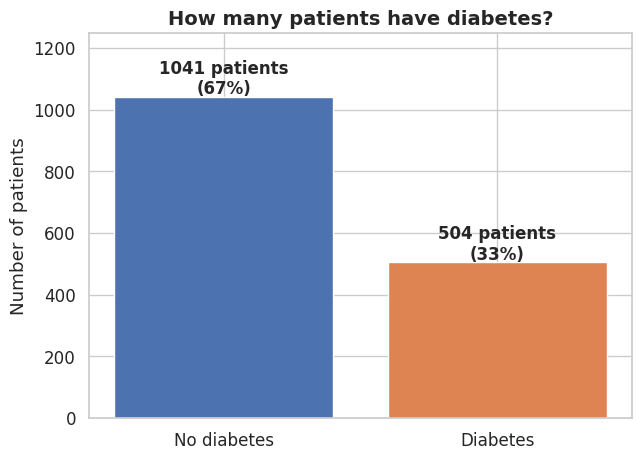

In [ ]:
counts = df["Diabetes"].value_counts().sort_index()
percent = counts / counts.sum() * 100

plt.figure(figsize=(7, 5))
bars = plt.bar([LABELS[0], LABELS[1]], counts, color=[COLORS[0], COLORS[1]])

for bar, c, p in zip(bars, counts, percent):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
             f"{c} patients\n({p:.0f}%)", ha="center", fontsize=12, fontweight="bold")

plt.title("How many patients have diabetes?", fontsize=14, fontweight="bold")
plt.ylabel("Number of patients")
plt.ylim(0, counts.max() * 1.2)
plt.show()

- The classes are imbalanced
- A model that always predicts "No diabetes" gets 67% accuracy without learning anything

### 2.3 Univariate: a numerical column (`Glucose`)

What is the typical glucose level?

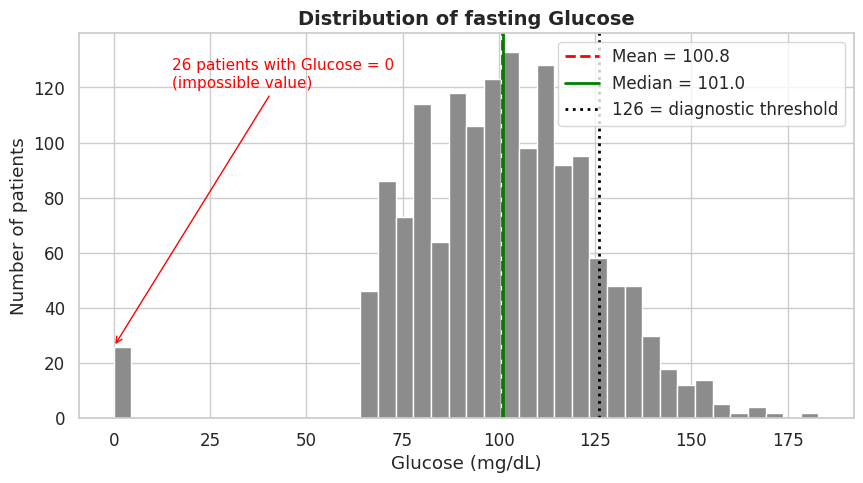

In [ ]:
glucose = df["Glucose"]

plt.figure(figsize=(10, 5))
plt.hist(glucose, bins=40, color="#8C8C8C", edgecolor="white")

plt.axvline(glucose.mean(), color="red", linestyle="--", linewidth=2,
            label=f"Mean = {glucose.mean():.1f}")
plt.axvline(glucose.median(), color="green", linestyle="-", linewidth=2,
            label=f"Median = {glucose.median():.1f}")
plt.axvline(126, color="black", linestyle=":", linewidth=2,
            label="126 = diagnostic threshold")

zeros = (glucose == 0).sum()
plt.annotate(f"{zeros} patients with Glucose = 0\n(impossible value)",
             xy=(0, zeros), xytext=(15, 120),
             arrowprops=dict(arrowstyle="->", color="red"), color="red", fontsize=11)

plt.title("Distribution of fasting Glucose", fontsize=14, fontweight="bold")
plt.xlabel("Glucose (mg/dL)")
plt.ylabel("Number of patients")
plt.legend()
plt.show()

- Most patients are between 80 and 130 mg/dL Glucose

- The bar at 0 is not real data, these are missing values recorded as 0

### 2.4 Univariate: a categorical column (`Gender`)

What values does this column contain?

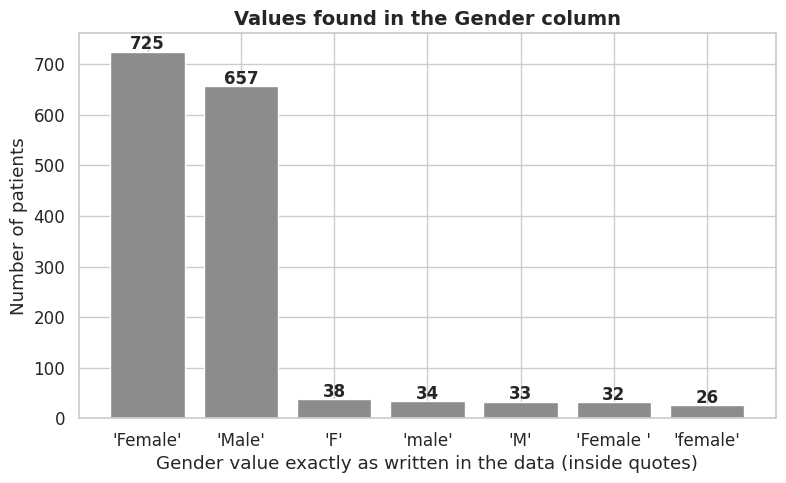

In [ ]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(9, 5))
bars = plt.bar([f"'{v}'" for v in gender_counts.index], gender_counts.values, color="#8C8C8C")

for bar, c in zip(bars, gender_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5, str(c),
             ha="center", fontsize=12, fontweight="bold")

plt.title("Values found in the Gender column", fontsize=14, fontweight="bold")
plt.xlabel("Gender value exactly as written in the data (inside quotes)")
plt.ylabel("Number of patients")
plt.show()

- There should be **2 categories**, but we find several: `Male`, `male`, and `M`
- `"Female "` has an **extra space at the end**
- **We must standardize and clean** these values (lowercase, remove spaces) before encoding

### 2.5 Bivariate: numerical vs target (`Glucose` vs `Diabetes`)

Do diabetic patients have higher glucose?

We ignore the zeros in this plot because we already know they are wrong.

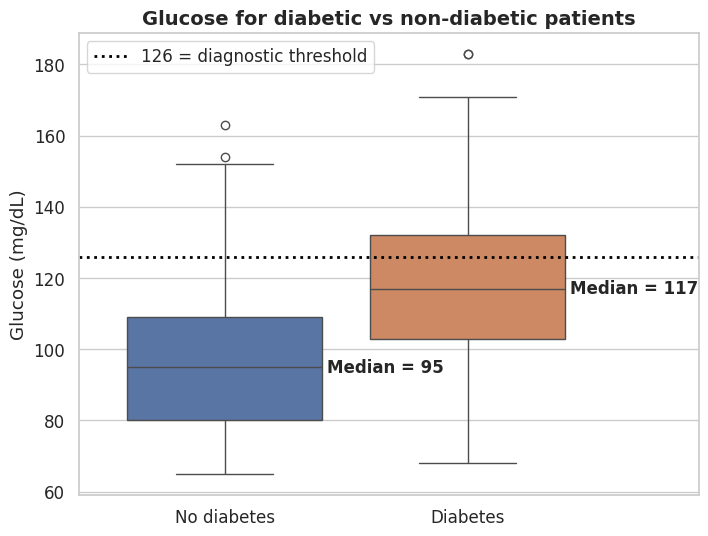

In [ ]:
valid = df[df["Glucose"] > 0]

plt.figure(figsize=(8, 6))
sns.boxplot(data=valid, x="Diabetes", y="Glucose", hue="Diabetes", palette=COLORS, legend=False)

for group in [0, 1]:
    median = valid.loc[valid["Diabetes"] == group, "Glucose"].median()
    plt.text(group + 0.42, median, f"Median = {median:.0f}",
             ha="left", va="center", fontsize=12, fontweight="bold")

plt.axhline(126, color="black", linestyle=":", linewidth=2, label="126 = diagnostic threshold")
plt.xticks([0, 1], [LABELS[0], LABELS[1]])
plt.xlim(-0.6, 1.95)
plt.title("Glucose for diabetic vs non-diabetic patients", fontsize=14, fontweight="bold")
plt.xlabel("")
plt.ylabel("Glucose (mg/dL)")
plt.legend(loc="upper left")
plt.show()

- Glucose greater than 122 mg/dL is generally considered a diabetic patient
However, some patients flagged as diabetic have glucose < 122 mg/dL
- The diabetic box is clearly higher, so `Glucose` separates the two groups well. It should be a strong feature
- The boxes **overlap**, so `Glucose` alone is not enough. We need other features and columns
- **In the overlapping region**, the model gets confused and makes false predictions:
  - Some patients are **above the line** but do **not have diabetes**
  - Some patients are **below the line** but **do have diabetes**

### 2.6 Bivariate: categorical vs target (`ActivityLevel` vs `Diabetes`)

Does physical activity change the diabetes rate?

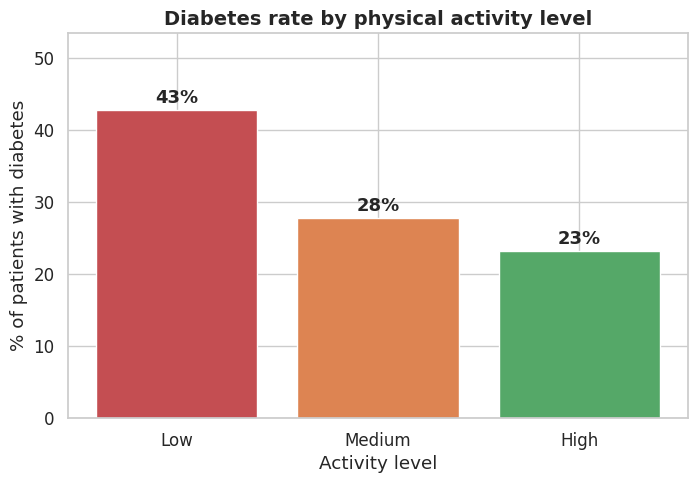

In [ ]:
rate = df.groupby("ActivityLevel")["Diabetes"].mean() * 100
rate = rate.reindex(["Low", "Medium", "High"])

plt.figure(figsize=(8, 5))
bars = plt.bar(rate.index, rate.values, color=["#C44E52", "#DD8452", "#55A868"])

for bar, r in zip(bars, rate.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{r:.0f}%",
             ha="center", fontsize=13, fontweight="bold")

plt.title("Diabetes rate by physical activity level", fontsize=14, fontweight="bold")
plt.xlabel("Activity level")
plt.ylabel("% of patients with diabetes")
plt.ylim(0, rate.max() * 1.25)
plt.show()

- This pattern matches real-world logic: low activity → higher diabetes risk; high activity → lower diabetes risk
- Diabetes rate decreases as activity increases: Low > Medium > High





### 2.7 Bivariate: numerical vs numerical (`Age` vs `Glucose`)

Does glucose rise with age? Where do the diabetic patients sit?

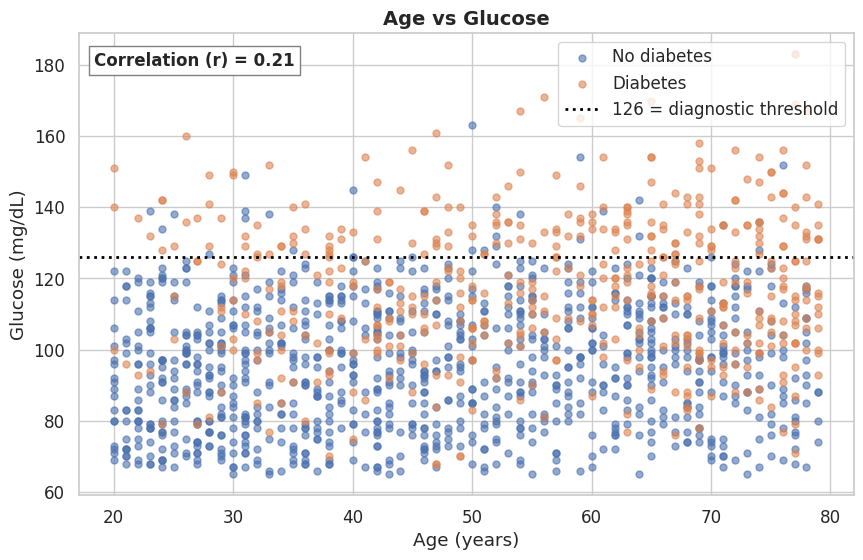

In [ ]:
valid = df[df["Glucose"] > 0]

plt.figure(figsize=(10, 6))
for group in [0, 1]:
    part = valid[valid["Diabetes"] == group]
    plt.scatter(part["Age"], part["Glucose"], color=COLORS[group], label=LABELS[group],
                alpha=0.6, s=25)

plt.axhline(126, color="black", linestyle=":", linewidth=2, label="126 = diagnostic threshold")

r = valid["Age"].corr(valid["Glucose"])
plt.text(0.02, 0.96, f"Correlation (r) = {r:.2f}", transform=plt.gca().transAxes,
         va="top", fontsize=12, fontweight="bold", bbox=dict(facecolor="white", edgecolor="gray"))

plt.title("Age vs Glucose", fontsize=14, fontweight="bold")
plt.xlabel("Age (years)")
plt.ylabel("Glucose (mg/dL)")
plt.legend(loc="upper right")
plt.show()

- older patients tend to have slightly higher glucose
- Orange dots (diabetes) cluster at the top, above the 126 mg/dL line
- Some patients are younger with diabetes and other is older without

## 3. Imputation (Missing Values)

**Step 1:** turn the hidden missing values (0) into real missing values (NaN), so we can see them.

In [ ]:
df["Glucose"] = df["Glucose"].replace(0, np.nan)
df["BloodPressure"] = df["BloodPressure"].replace(0, np.nan)

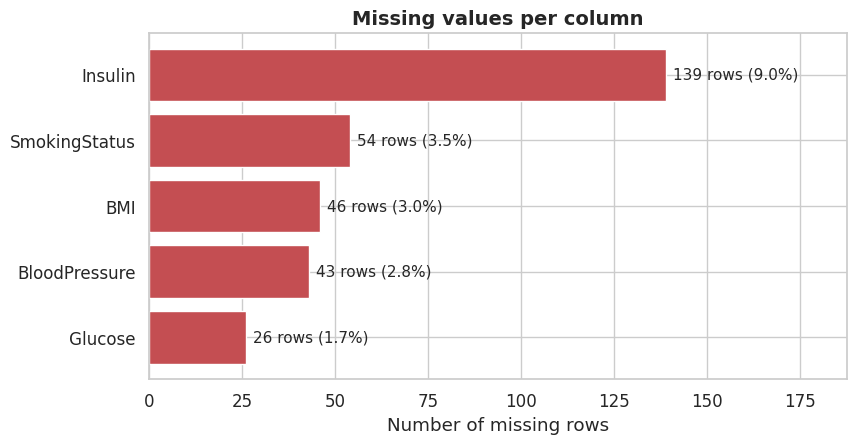

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values()
missing_percent = missing / len(df) * 100

plt.figure(figsize=(9, 4.5))
bars = plt.barh(missing.index, missing.values, color="#C44E52")

for bar, m, p in zip(bars, missing.values, missing_percent.values):
    plt.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
             f"{m} rows ({p:.1f}%)", va="center", fontsize=11)

plt.title("Missing values per column", fontsize=14, fontweight="bold")
plt.xlabel("Number of missing rows")
plt.xlim(0, missing.max() * 1.35)
plt.show()

- Numerical columns:  Use Median or mean but this is health data therefor better to use the median for the almost standered or well knownen range
- Categorical columns: Use Mode (most frequent value)
- Better approach is group by most correlated features

In [ ]:
numerical_cols = ["BMI", "Glucose", "BloodPressure", "Insulin"]

for col in numerical_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)
    print(f"{col}: filled with median = {median_value}")

mode_value = df["SmokingStatus"].mode()[0]
df["SmokingStatus"] = df["SmokingStatus"].fillna(mode_value)
print(f"SmokingStatus: filled with mode = {mode_value}")

BMI: filled with median = 27.7
Glucose: filled with median = 102.0
BloodPressure: filled with median = 75.0
Insulin: filled with median = 101.0
SmokingStatus: filled with mode = Never


In [ ]:
print("Missing values after imputation:", df.isnull().sum().sum())

Missing values after imputation: 0


## 4. Wranglling

### 4.1 Duplicated rows

The same patient recorded twice. If one copy goes to training and the other to testing, the model is tested on a patient it has already seen, so the score looks better than it really is.

In [ ]:
print("Rows before:", len(df))
print("Duplicated rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Rows after:", len(df))

Rows before: 1545
Duplicated rows: 45
Rows after: 1500


Drop duplicate rows: no investigation needed since the patient is the same (redundant data)

### 4.2 Inconsistent text in `Gender`

Two steps: remove extra spaces and unify the letter case, then map every spelling to one standard value.

In [ ]:
print("Before:", list(df["Gender"].unique()))

df["Gender"] = df["Gender"].str.strip().str.lower()

df["Gender"] = df["Gender"].replace({
    "m": "male",
    "f": "female",
})

print("After: ", list(df["Gender"].unique()))

Before: ['Male', 'Female', 'female', 'Female ', 'male', 'M', 'F']
After:  ['male', 'female']


In [ ]:
df = df.drop(columns=["PatientID"])

- PatientID is just an identifier with no medical meaning
- It has very high std, which can cause bias in the model
- Drop it before training

## 5. Encoding

In [ ]:
df["Gender"] = df["Gender"].map({"female": 0, "male": 1})

df["FamilyHistory"] = df["FamilyHistory"].map({"No": 0, "Yes": 1})

df["ActivityLevel"] = df["ActivityLevel"].map({"Low": 0, "Medium": 1, "High": 2})

df = pd.get_dummies(df, columns=["SmokingStatus"], prefix="Smoking", dtype=int)

df.head()

,Age,Gender,BMI,Glucose,BloodPressure,Insulin,FamilyHistory,ActivityLevel,Diabetes,Smoking_Current,Smoking_Former,Smoking_Never
0,48,1,28.4,86.0,61.0,94.0,0,0,0,0,0,1
1,50,1,19.9,106.0,69.0,99.0,1,1,1,1,0,0
2,69,0,28.6,153.0,60.0,121.0,0,1,1,0,0,1
3,65,0,27.5,105.0,66.0,137.0,0,2,0,1,0,0
4,42,0,36.4,123.0,95.0,165.0,0,2,0,0,0,1


- Convert categorical columns into numbers so the model can read them
- Columns with **2 categories** (`Gender`, `FamilyHistory`) are converted to **0 and 1** (Binary Encoding)
- `SmokingStatus` has **more than 2 categories**, so it cannot be converted to 0 and 1
- For `SmokingStatus`, we use **One-Hot Encoding**, which creates a separate 0/1 column for each category

## 6. Correlation Matrix

Now every column is a number, so we can measure the relationship between each columns.

We show only the lower half, because the upper half is a mirror copy.

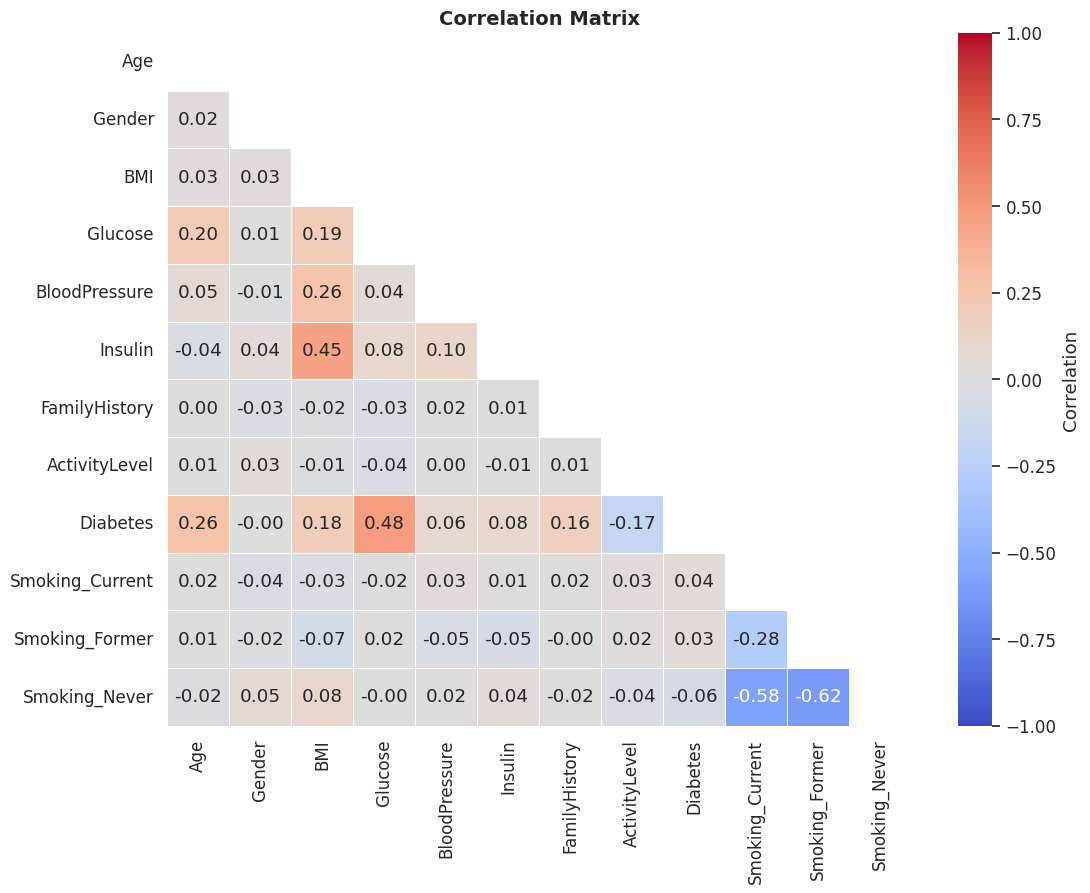

In [ ]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, linewidths=0.5, cbar_kws={"label": "Correlation"})
plt.grid(False)
plt.title("Correlation Matrix", fontsize=14, fontweight="bold")
plt.show()

Glucose has the strongest correlation with Diabetes (0.48), followed by Age (0.26), BMI (0.18), and FamilyHistory (0.16), while ActivityLevel is negative (-0.17), meaning more activity lowers diabetes risk

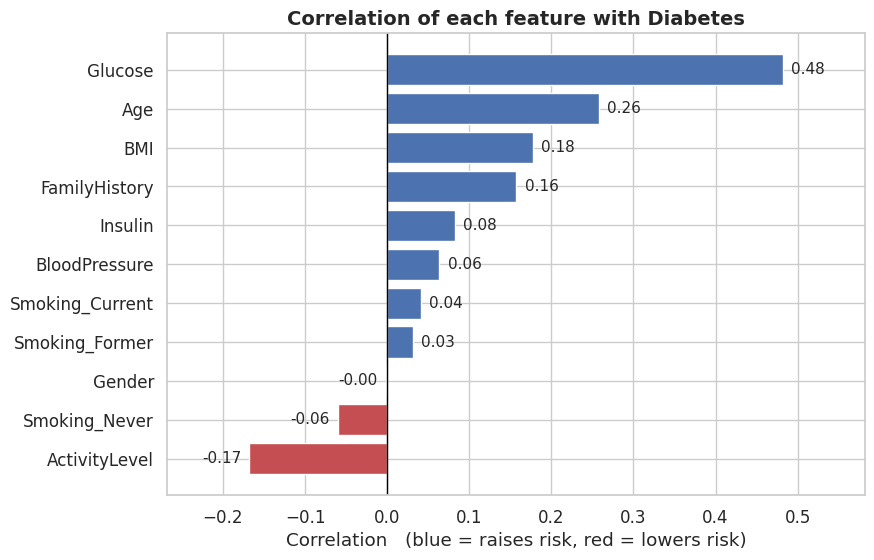

In [ ]:
target_corr = corr["Diabetes"].drop("Diabetes").sort_values()
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in target_corr.values]

plt.figure(figsize=(9, 6))
bars = plt.barh(target_corr.index, target_corr.values, color=colors)

for bar, v in zip(bars, target_corr.values):
    offset = 0.01 if v >= 0 else -0.01
    align = "left" if v >= 0 else "right"
    plt.text(v + offset, bar.get_y() + bar.get_height() / 2, f"{v:.2f}",
             va="center", ha=align, fontsize=11)

plt.axvline(0, color="black", linewidth=1)
plt.title("Correlation of each feature with Diabetes", fontsize=14, fontweight="bold")
plt.xlabel("Correlation   (blue = raises risk, red = lowers risk)")
plt.xlim(target_corr.min() - 0.1, target_corr.max() + 0.1)
plt.show()

## 7. Train/Test Split and Standardization

### 7.1 Split

```
All data
 ├── Train (80%) : the model learns from it
 └── Test  (20%) : new patients the model has never seen, used once at the end
```
`stratify=y` keeps the same diabetes ratio in both parts.

We remove Diabetes from X because it is the target, the answer we want the model to predict to avoid the data leakage

In [ ]:
X = df.drop(columns=["Diabetes"])#Target Leakage.
y = df["Diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print("Train:", X_train.shape, "  Diabetes rate:", round(y_train.mean(), 2))
print("Test: ", X_test.shape, "  Diabetes rate:", round(y_test.mean(), 2))

Train: (1200, 11)   Diabetes rate: 0.33
Test:  (300, 11)   Diabetes rate: 0.33


### 7.2 Standardization

Features have very different scales: `Age` is around 50, `Insulin` around 100, `Gender` is 0 or 1.
**StandardScaler** converts each column so that its mean = 0 and its standard deviation = 1:

`z = (value - mean) / std`

**Which columns?** Only the continuous numerical ones. Binary and one-hot columns are already 0/1.

**Rule:** `fit` on Train only (learn the mean and std), then `transform` both Train and Test.

> **Note:** tree models like XGBoost and LightGBM do not need scaling, because a split like "Glucose > 126" works the same on any scale. Scaling matters for models based on distance or weights, such as Logistic Regression, KNN, SVM, and Neural Networks. We apply it here so the pipeline is complete.

In [ ]:
scale_cols = ["Age", "BMI", "Glucose", "BloodPressure", "Insulin"]

scaler = StandardScaler()
scaler.fit(X_train[scale_cols])  # learn from Train only

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[scale_cols] = scaler.transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

comparison = pd.DataFrame({
    "Mean before": X_train[scale_cols].mean(),
    "Std before": X_train[scale_cols].std(),
    "Mean after": X_train_scaled[scale_cols].mean(),
    "Std after": X_train_scaled[scale_cols].std(),
}).round(2)
comparison

,Mean before,Std before,Mean after,Std after
Age,49.61,17.30,-0.0,1.0
BMI,27.99,5.81,-0.0,1.0
Glucose,102.22,21.01,-0.0,1.0
BloodPressure,74.84,9.16,0.0,1.0
Insulin,101.48,37.82,-0.0,1.0


## 8. Models

Both models use **Gradient Boosting**: many small trees are built one after another, and each new tree corrects the mistakes of the previous ones.

**XGBoost vs LightGBM:**
- **Tree growth:** XGBoost grows **level-wise** (completes each level before the next); LightGBM grows **leaf-wise** (expands the leaf with the biggest error)
- **Speed:** XGBoost is good; LightGBM is faster on large datasets
- **Size control:** XGBoost uses `max_depth`; LightGBM uses `num_leaves`

### Parameters vs Hyperparameters
- **Hyperparameters** are set **by us before training** (e.g. number of trees, learning rate, depth)
- **Parameters** are learned **by the model during training** (e.g. split points like `Glucose > 126`, leaf values)

### 8.1 XGBoost
- `n_estimators = 300`: number of trees
- `learning_rate = 0.05`: how much each tree corrects; smaller is slower but more stable
- `max_depth = 4`: maximum number of questions in one tree path
- `subsample = 0.8`: each tree sees 80% of the patients
- `colsample_bytree = 0.8`: each tree sees 80% of the features

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    enable_categorical=False
)

xgb_model.fit(X_train_scaled, y_train)

xgb_pred = xgb_model.predict(X_test_scaled)                  # 0 or 1
xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]      # probability of diabetes

### 8.2 LightGBM

| Hyperparameter | Value | Meaning |
|---|---|---|
| `n_estimators` | 300 | Number of trees |
| `learning_rate` | 0.05 | How much each tree corrects |
| `num_leaves` | 15 | Maximum leaves per tree (main control, because growth is leaf-wise) |
| `min_child_samples` | 20 | Minimum patients in a leaf, prevents very specific leaves |
| `subsample` | 0.8 | Each tree sees 80% of the patients |
| `colsample_bytree` | 0.8 | Each tree sees 80% of the features |

In [ ]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=15,
    min_child_samples=20,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)

lgbm_model.fit(X_train_scaled, y_train)

lgbm_pred = lgbm_model.predict(X_test_scaled)
lgbm_prob = lgbm_model.predict_proba(X_test_scaled)[:, 1]

## 9. Exercise: compute the metrics yourself

Below are **20 patients** from the test set: what really happened (`Actual`) and what XGBoost predicted (`Predicted`).

**Your task, with pen and paper:**
1. Label each row as **TP**, **TN**, **FP**, or **FN**
2. Count each one
3. Compute: **Accuracy**, **Precision**, **Recall**, **F1 Score**

In [ ]:
exercise = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": xgb_pred,
}).sample(20, random_state=119).reset_index(drop=True)

exercise.index = exercise.index + 1
exercise.index.name = "Patient"
exercise

,Actual,Predicted
Patient,,
1,1,1
2,1,1
3,1,1
4,0,1
5,0,0
6,0,0
7,1,1
8,0,0
9,0,0


**Stop here and solve it before scrolling down.**

<br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br>

## 10. Answers

### 10.1 The 20 patients, labeled

In [ ]:
def outcome(row):
    if row["Actual"] == 1 and row["Predicted"] == 1:
        return "TP"
    if row["Actual"] == 0 and row["Predicted"] == 0:
        return "TN"
    if row["Actual"] == 0 and row["Predicted"] == 1:
        return "FP"
    return "FN"

exercise["Outcome"] = exercise.apply(outcome, axis=1)
exercise

,Actual,Predicted,Outcome
Patient,,,
1,1,1,TP
2,1,1,TP
3,1,1,TP
4,0,1,FP
5,0,0,TN
6,0,0,TN
7,1,1,TP
8,0,0,TN
9,0,0,TN


### 10.2 Confusion Matrix and metrics for the 20 patients

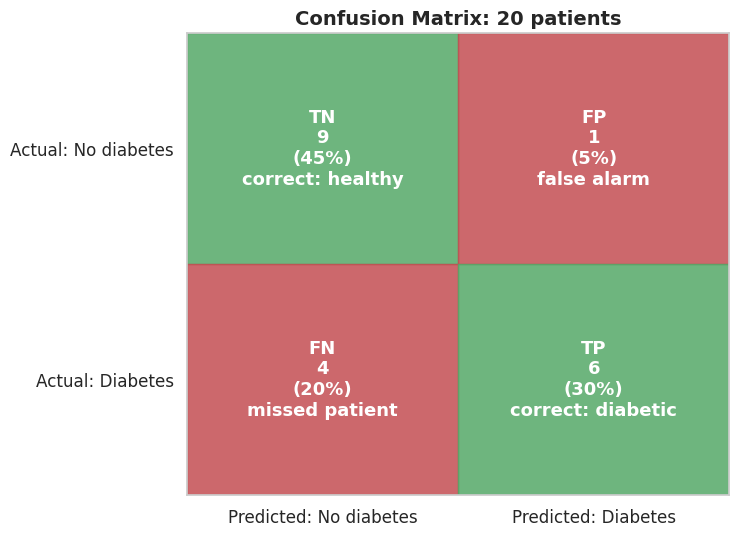

TP = 6   TN = 9   FP = 1   FN = 4   Total = 20

Accuracy  = (TP + TN) / Total        = (6 + 9) / 20       = 0.750
Precision = TP / (TP + FP)           = 6 / (6 + 1)         = 0.857
Recall    = TP / (TP + FN)           = 6 / (6 + 4)         = 0.600
F1 Score  = 2 * P * R / (P + R)      = 2 * 0.857 * 0.600 / (0.857 + 0.600) = 0.706


In [ ]:
def plot_confusion_matrix(actual, predicted, title):
    cm = confusion_matrix(actual, predicted)
    names = [["TN", "FP"], ["FN", "TP"]]
    meaning = [["correct: healthy", "false alarm"], ["missed patient", "correct: diabetic"]]
    colors = [["#55A868", "#C44E52"], ["#C44E52", "#55A868"]]
    total = cm.sum()

    fig, ax = plt.subplots(figsize=(7, 6))
    for i in range(2):
        for j in range(2):
            ax.add_patch(plt.Rectangle((j, i), 1, 1, color=colors[i][j], alpha=0.85))
            ax.text(j + 0.5, i + 0.5,
                    f"{names[i][j]}\n{cm[i, j]}\n({cm[i, j] / total:.0%})\n{meaning[i][j]}",
                    ha="center", va="center", fontsize=13, color="white", fontweight="bold")

    ax.set_xlim(0, 2)
    ax.set_ylim(2, 0)
    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(["Predicted: No diabetes", "Predicted: Diabetes"])
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(["Actual: No diabetes", "Actual: Diabetes"])
    ax.grid(False)
    ax.set_title(title, fontsize=14, fontweight="bold")
    plt.show()


def explain_metrics(actual, predicted):
    tn, fp, fn, tp = confusion_matrix(actual, predicted).ravel()
    total = tp + tn + fp + fn

    accuracy = (tp + tn) / total
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2 * precision * recall / (precision + recall)

    print(f"TP = {tp}   TN = {tn}   FP = {fp}   FN = {fn}   Total = {total}")
    print()
    print(f"Accuracy  = (TP + TN) / Total        = ({tp} + {tn}) / {total}       = {accuracy:.3f}")
    print(f"Precision = TP / (TP + FP)           = {tp} / ({tp} + {fp})         = {precision:.3f}")
    print(f"Recall    = TP / (TP + FN)           = {tp} / ({tp} + {fn})         = {recall:.3f}")
    print(f"F1 Score  = 2 * P * R / (P + R)      = 2 * {precision:.3f} * {recall:.3f} / ({precision:.3f} + {recall:.3f}) = {f1:.3f}")


plot_confusion_matrix(exercise["Actual"], exercise["Predicted"], "Confusion Matrix: 20 patients")
explain_metrics(exercise["Actual"], exercise["Predicted"])

### 10.3 The full test set: XGBoost

Same formulas, now on all test patients.

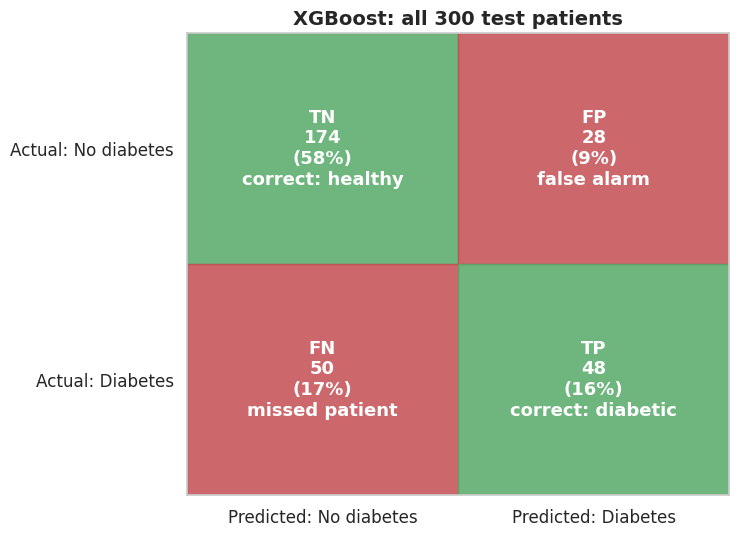

TP = 48   TN = 174   FP = 28   FN = 50   Total = 300

Accuracy  = (TP + TN) / Total        = (48 + 174) / 300       = 0.740
Precision = TP / (TP + FP)           = 48 / (48 + 28)         = 0.632
Recall    = TP / (TP + FN)           = 48 / (48 + 50)         = 0.490
F1 Score  = 2 * P * R / (P + R)      = 2 * 0.632 * 0.490 / (0.632 + 0.490) = 0.552


In [ ]:
plot_confusion_matrix(y_test, xgb_pred, f"XGBoost: all {len(y_test)} test patients")
explain_metrics(y_test, xgb_pred)

### 10.4 The full test set: LightGBM

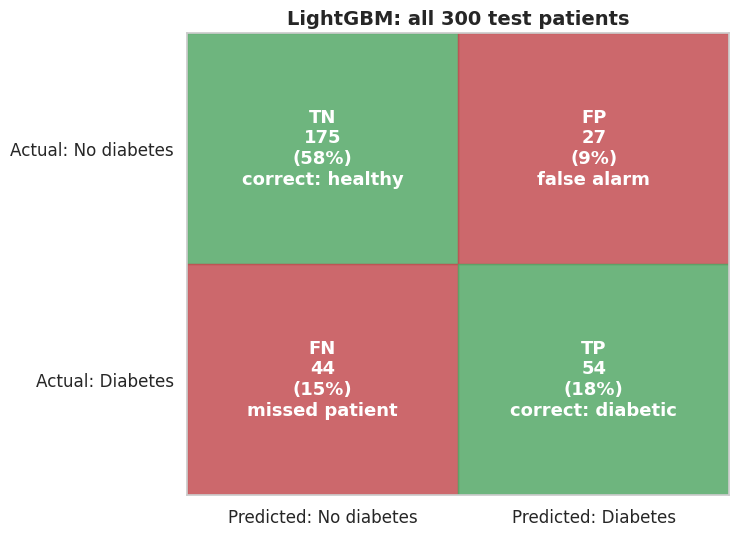

TP = 54   TN = 175   FP = 27   FN = 44   Total = 300

Accuracy  = (TP + TN) / Total        = (54 + 175) / 300       = 0.763
Precision = TP / (TP + FP)           = 54 / (54 + 27)         = 0.667
Recall    = TP / (TP + FN)           = 54 / (54 + 44)         = 0.551
F1 Score  = 2 * P * R / (P + R)      = 2 * 0.667 * 0.551 / (0.667 + 0.551) = 0.603


In [ ]:
plot_confusion_matrix(y_test, lgbm_pred, f"LightGBM: all {len(y_test)} test patients")
explain_metrics(y_test, lgbm_pred)

### 10.5 ROC-AUC and PR-AUC

Accuracy, Precision, Recall, and F1 use **one** threshold (0.5). These two curves check **every** threshold.

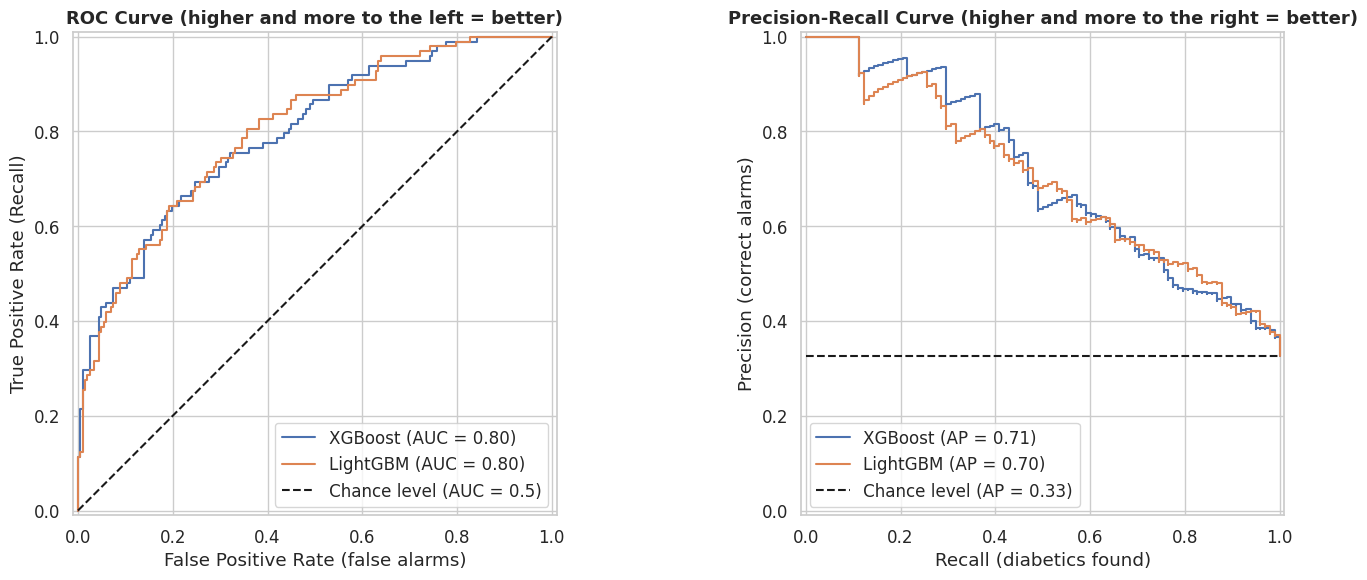

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

RocCurveDisplay.from_predictions(y_test, xgb_prob, name="XGBoost", ax=axes[0])
RocCurveDisplay.from_predictions(y_test, lgbm_prob, name="LightGBM", ax=axes[0], plot_chance_level=True)
axes[0].set_title("ROC Curve (higher and more to the left = better)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("False Positive Rate (false alarms)")
axes[0].set_ylabel("True Positive Rate (Recall)")

PrecisionRecallDisplay.from_predictions(y_test, xgb_prob, name="XGBoost", ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_test, lgbm_prob, name="LightGBM", ax=axes[1], plot_chance_level=True)
axes[1].set_title("Precision-Recall Curve (higher and more to the right = better)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Recall (diabetics found)")
axes[1].set_ylabel("Precision (correct alarms)")

plt.tight_layout()
plt.show()

### 10.6 All metrics side by side

In [ ]:
def all_metrics(actual, predicted, probability):
    return {
        "Accuracy": accuracy_score(actual, predicted),
        "Precision": precision_score(actual, predicted),
        "Recall": recall_score(actual, predicted),
        "F1 Score": f1_score(actual, predicted),
        "ROC-AUC": roc_auc_score(actual, probability),
        "PR-AUC": average_precision_score(actual, probability),
    }

results = pd.DataFrame({
    "XGBoost": all_metrics(y_test, xgb_pred, xgb_prob),
    "LightGBM": all_metrics(y_test, lgbm_pred, lgbm_prob),
}).round(3)

results

,XGBoost,LightGBM
Accuracy,0.740,0.763
Precision,0.632,0.667
Recall,0.490,0.551
F1 Score,0.552,0.603
ROC-AUC,0.798,0.803
PR-AUC,0.709,0.700


 Recall is most cretical, because a missed diabetic patient (FN) goes without treatment, while a false alarm (FP) only costs one extra blood test.

## 11. SHAP: why did the model decide this?

**Idea:** start from the average patient's risk, then each feature pushes the prediction up or down:
```
Average risk of all patients         30%
+ Glucose is high                   +35%
+ FamilyHistory = Yes               +10%
+ ActivityLevel = High               -8%
= Model prediction for this patient  67%
```
- **Positive SHAP value:** the feature raised the risk
- **Negative SHAP value:** the feature lowered the risk
- **Average + all SHAP values = the model's prediction**

In [ ]:
explainer = shap.TreeExplainer(
    xgb_model,
    data=X_train_scaled.sample(200, random_state=0).values,
    model_output="raw",
    feature_perturbation="tree_path_dependent"
)
shap_values = explainer(X_test_scaled.values)
shap_values.data = X_test.values          # show original values (not scaled) in the plots

print("Average risk (starting point):", round(shap_values.base_values[0], 2))

Average risk (starting point): -1.2


### 11.1 Which features matter most? (Global)

The average size of each feature's push, across all test patients.

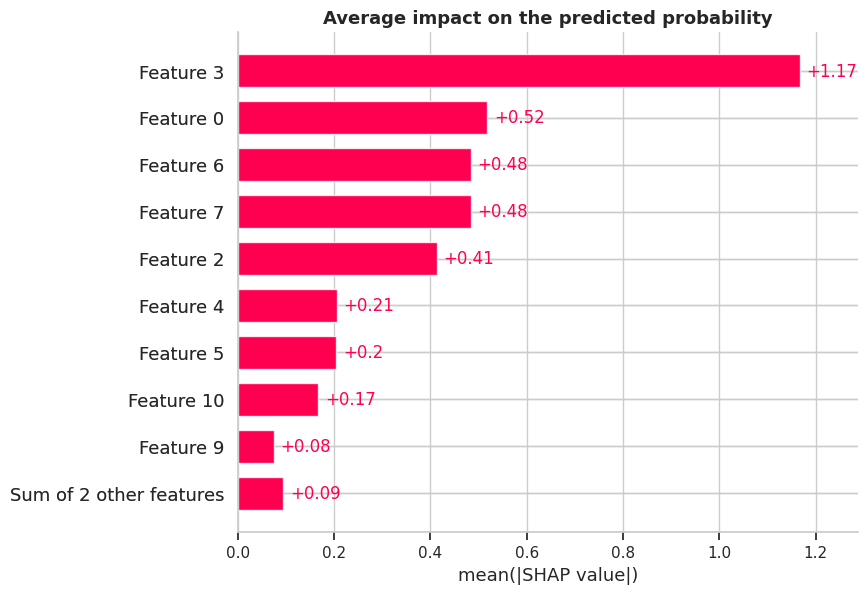

In [ ]:
shap.plots.bar(shap_values, show=False)
plt.title("Average impact on the predicted probability", fontsize=13, fontweight="bold")
plt.show()

### 11.2 In which direction? (Beeswarm)

- Each dot = one patient
- **Red** = high value of the feature, **blue** = low value
- **Right** of the center line = raises the risk, **left** = lowers it

Example: `Glucose` red dots are on the right (high sugar raises risk). `ActivityLevel` red dots are on the left (more activity lowers risk).

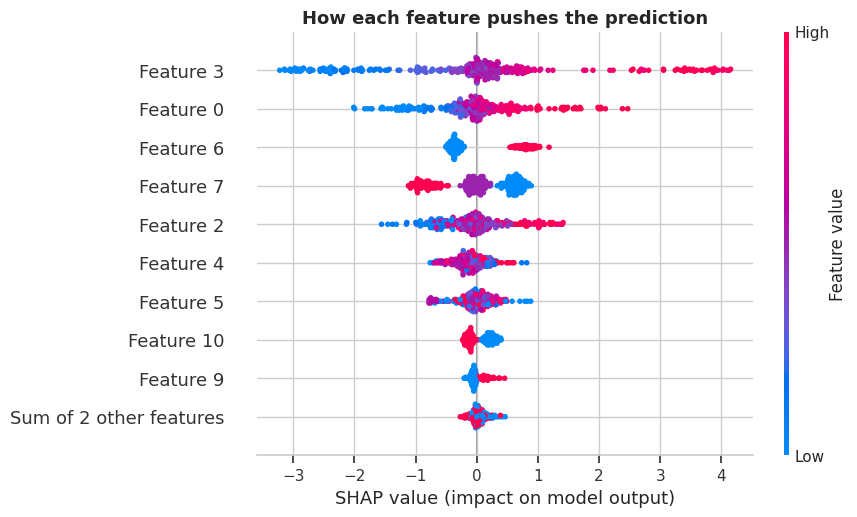

In [ ]:
shap.plots.beeswarm(shap_values, show=False)
plt.title("How each feature pushes the prediction", fontsize=13, fontweight="bold")
plt.show()

### 11.3 One patient (Local)

Read from the **bottom** up: start at `E[f(X)]` (average risk), each bar pushes right (red, raises risk) or left (blue, lowers risk), and we end at `f(x)`, this patient's predicted probability.

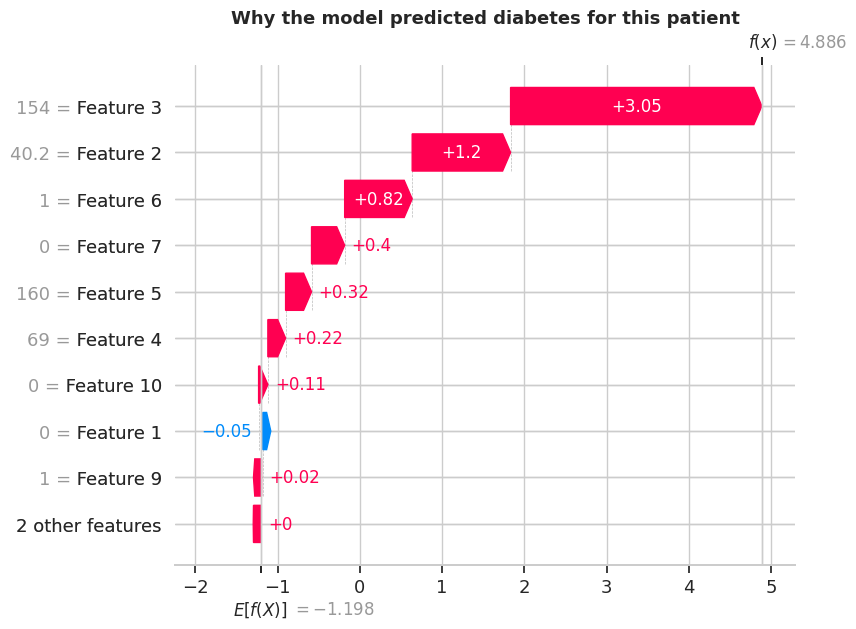

In [ ]:
patient = int(np.argmax(xgb_prob))            # the highest-risk patient in the test set

shap.plots.waterfall(shap_values[patient], show=False)
plt.title("Why the model predicted diabetes for this patient", fontsize=13, fontweight="bold")
plt.show()